# RoPE — Rotary Position Embedding, from the problem to the code

> **RoFormer: Enhanced Transformer with Rotary Position Embedding**
> Jianlin Su, Yu Lu, Shengfeng Pan, Ahmed Murtadha, Bo Wen, Yunfeng Liu — [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)

RoPE is the position encoding inside LLaMA, Mistral, Qwen, DeepSeek, GPT-NeoX, PaLM,
Gemma — essentially every modern decoder. This notebook rebuilds it in PyTorch and,
more importantly, **verifies each claim the paper makes** instead of taking it on faith.

**Files in this folder**

| File | What it is |
| --- | --- |
| `rope.ipynb` | this notebook — the derivation and the experiments |
| `rope.py` | the clean library: rotation, attention, a tiny transformer, linear attention |
| `task.py` | a position-critical toy task + training loop used for the comparisons |
| `test_rope.py` | pytest assertions for every property the paper claims (`make test`) |

**Run it**: from `Research_Paper/` do `make setup` once, then `make lab` and pick the
`Python (research-papers)` kernel.

## The questions this notebook answers

Each section is one question. The answer is at the end of the section, backed by
something we actually computed — not by a quote from the paper.

| # | Question | Where the answer comes from |
| --- | --- | --- |
| **Q1** | Why does a transformer need position information at all? | permutation test on raw attention |
| **Q2** | What is wrong with the position encodings we already had? | shift test + a parameter/length audit |
| **Q3** | What *exactly* is the paper asking for, and what is the 2-D solution? | the requirement equation, solved with complex numbers |
| **Q4** | How does a 2-D rotation become a $d$-dimensional one you can afford? | block-diagonal $R_{\Theta,m}$ vs. the 3-line elementwise form |
| **Q5** | Does RoPE really make attention depend on $m-n$ only? | exact numerical shift test + logit heatmaps |
| **Q6** | Does attention decay as tokens get further apart? | the paper's §3.4.3 bound + an empirical measurement |
| **Q7** | Does any of this help a model that has to learn something? | 4 models trained here, same seed, only the PE differs |
| **Q8** | Does it survive linear attention, where relative biases cannot go? | §3.3, implemented and shift-tested |
| **Q9** | What does RoPE *not* fix? | the honest limitations section at the end |

In [1]:
import math, time, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

sys.path.insert(0, ".")          # so `import rope` works when Jupyter starts elsewhere
import rope as R
import task as T

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"python {sys.version.split()[0]} | torch {torch.__version__} | device {DEVICE}")

python 3.12.14 | torch 2.13.0+cu130 | device cuda


In [2]:
# ── plotting theme ──────────────────────────────────────────────────────────────
# One validated categorical palette, assigned in fixed slot order so a colour always
# means the same model. Sequential = one hue light→dark. Signed = diverging blue↔red
# with a neutral grey midpoint.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
PE_COLOR = {                       # slot 1..4, never cycled
    "rope":       "#2a78d6",       # blue
    "learned":    "#eb6834",       # orange
    "sinusoidal": "#1baf7a",       # aqua
    "none":       "#eda100",       # yellow
}
PE_LABEL = {"rope": "RoPE", "learned": "learned absolute",
            "sinusoidal": "sinusoidal absolute", "none": "no position encoding"}

SEQ = LinearSegmentedColormap.from_list("seq_blue", [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_br", [
    "#184f95", "#3987e5", "#9ec5f4", "#f0efec", "#f5a3a2", "#e34948", "#a11f1e"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 120,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.direction": "out", "ytick.direction": "out",
    "grid.color": GRID, "grid.linewidth": 0.7, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 8.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5, "lines.solid_capstyle": "round",
    "font.size": 9.5,
})

def label_end(ax, x, y, text, color, dx=4):
    """Direct label at the end of a line - identity is never colour-alone."""
    ax.annotate(text, (x, y), textcoords="offset points", xytext=(dx, 0),
                va="center", ha="left", fontsize=8.5, color=color, weight="bold",
                clip_on=False)

def label_ends(ax, items, dx=6, min_gap=11.0):
    """Direct-label several line ends, nudged apart in pixels so they never overlap.

    items: iterable of (x, y, text, color).
    """
    inv = ax.transData.inverted()
    rows = sorted(((ax.transData.transform((x, y))[1], x, y, txt, c)
                   for x, y, txt, c in items), key=lambda r: r[0])
    last = None
    for py, x, _y, txt, c in rows:
        if last is not None and py - last < min_gap:
            py = last + min_gap
        last = py
        ax.annotate(txt, (x, inv.transform((0, py))[1]), textcoords="offset points",
                    xytext=(dx, 0), va="center", ha="left", fontsize=8.5,
                    color=c, weight="bold", clip_on=False)

def show_table(df, caption=None):
    """A table view always exists next to a chart."""
    return df.style.set_caption(caption or "").format(precision=3)

---
## Q1 — Why does a transformer need position information at all?

Because self-attention has no idea what order the tokens came in.

$$\text{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

Every term is a dot product between two token vectors. Nothing in that expression
mentions *where* a token sits. Formally, attention is **permutation-equivariant**:
shuffle the inputs and the outputs come back shuffled the same way, byte for byte.
So `"dog bites man"` and `"man bites dog"` produce the same set of representations.

Let's confirm that rather than assert it.

In [3]:
def bare_attention(x, Wq, Wk, Wv):
    # plain non-causal single-head attention - no position information anywhere
    q, k, v = x @ Wq, x @ Wk, x @ Wv
    return F.softmax(q @ k.T / math.sqrt(x.shape[-1]), dim=-1) @ v

g = torch.Generator().manual_seed(0)
d, t = 16, 6
Wq, Wk, Wv = (torch.randn(d, d, generator=g) / math.sqrt(d) for _ in range(3))
x = torch.randn(t, d, generator=g)

perm = torch.randperm(t, generator=g)
out_then_perm = bare_attention(x, Wq, Wk, Wv)[perm]   # attend, then shuffle
perm_then_out = bare_attention(x[perm], Wq, Wk, Wv)   # shuffle, then attend

print("permutation used:", perm.tolist())
print("max |difference| :", (out_then_perm - perm_then_out).abs().max().item())
assert torch.allclose(out_then_perm, perm_then_out, atol=1e-6)
print("\nIdentical -> attention cannot tell the two orderings apart.")

permutation used: [3, 5, 1, 2, 4, 0]
max |difference| : 1.7881393432617188e-07

Identical -> attention cannot tell the two orderings apart.


**Answer to Q1.** Order information has to be *injected*; attention will never
recover it on its own. Two families of injection existed before RoPE:

- **absolute** — give token $m$ a vector $\boldsymbol p_m$ and add it to the embedding:
  $\boldsymbol x_m \leftarrow \boldsymbol x_m + \boldsymbol p_m$ (sinusoidal, or learned).
- **relative** — leave the embeddings alone and add a bias to the attention *logit*
  that depends on $m-n$ (Shaw et al., T5, Transformer-XL).

Q2 is about why neither is satisfying.

### A concrete before-and-after, on a sentence

Abstract vectors are easy to wave through, so here is the same point on words.

Consider one very ordinary thing an attention head has to do: **look one token back**.
In `"the cat sat on the mat"`, the head reading `sat` wants `cat`. That is a *relative*
job — "one to my left" — and it should cost the same whether the phrase opens the
document or appears 200 tokens in.

We build a head that is good at exactly this job, then ask it the same question twice:
once with `"the cat sat ..."` at the start of the sequence, once with the identical
phrase sitting after 200 tokens of filler. **Before RoPE** (absolute PE) versus
**after RoPE** (rotation), same weights, same words.

In [4]:
SENT = ["the", "cat", "sat", "on", "the", "mat"]
FILLER = "<pad>"
VOCAB = [FILLER] + sorted(set(SENT))
IDX = {w: i for i, w in enumerate(VOCAB)}

d_head = 32
g = torch.Generator().manual_seed(11)
E  = torch.randn(len(VOCAB), d_head, generator=g)      # a toy embedding table
Wq = torch.randn(d_head, d_head, generator=g) / math.sqrt(d_head)
Wk = torch.randn(d_head, d_head, generator=g) / math.sqrt(d_head)

cos, sin = R.rope_cache(d_head, 1024)
pe = R.sinusoidal_pe(1024, d_head)

def head_logits(words, start, scheme):
    # full logit matrix for `words`, placed so that words[0] sits at absolute `start`
    x = E[[IDX[w] for w in words]]
    if scheme == "no position":
        q, k = x @ Wq.T, x @ Wk.T
    elif scheme == "absolute PE":
        xp = x + pe[start:start + len(words)]
        q, k = xp @ Wq.T, xp @ Wk.T
    elif scheme == "RoPE":
        q, k = x @ Wq.T, x @ Wk.T
        q = R.apply_rope(q.unsqueeze(0), cos, sin, start)[0]
        k = R.apply_rope(k.unsqueeze(0), cos, sin, start)[0]
    return q @ k.T / math.sqrt(d_head)

# the question: how strongly does 'sat' (index 2) attend to 'cat' (index 1)?
rows = []
for scheme in ["no position", "absolute PE", "RoPE"]:
    at_0   = head_logits(SENT, 0,   scheme)[2, 1].item()
    at_200 = head_logits(SENT, 200, scheme)[2, 1].item()
    rows.append({"scheme": scheme,
                 "logit(sat -> cat) at position 2": at_0,
                 "logit(sat -> cat) at position 202": at_200,
                 "change": at_200 - at_0})
show_table(pd.DataFrame(rows).set_index("scheme"),
           "The same two words, the same gap, moved 200 tokens later")

,logit(sat -> cat) at position 2,logit(sat -> cat) at position 202,change
scheme,,,
no position,-0.417,-0.417,0.000
absolute PE,1.211,-0.458,-1.669
RoPE,-0.358,-0.358,-0.000


Read the last column.

- **No position encoding** — nothing changes, but only because the head is blind to
  position altogether. It cannot prefer "one to my left" over "seven to my right"; the
  number is the same for every pair of these two words anywhere. Useless for the job.
- **Absolute PE** — the score moves. The head that learned `sat → cat` at position 2 is
  scoring a *different* number at position 202, so whatever threshold or competition it
  won at the start of the document, it may lose later on. This is the leak from Q2a,
  in units you can read.
- **RoPE** — the change is zero to floating-point precision, *and* the head still
  distinguishes distances. Position went in, absolute position came out.

Below is the whole logit matrix for the sentence at both locations, which shows the
second half of that claim: RoPE's matrix is not flat, it is *diagonal-structured* —
the score depends on the gap, so "one to my left" is a thing the head can express.

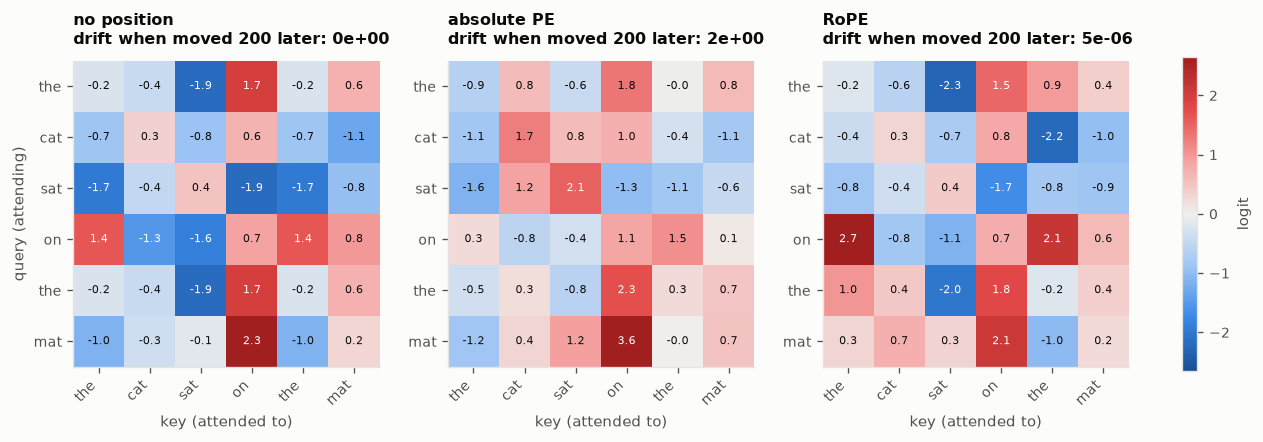

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.6), constrained_layout=True)
fig.get_layout_engine().set(w_pad=0.12)
for ax, scheme in zip(axes, ["no position", "absolute PE", "RoPE"]):
    a = head_logits(SENT, 0, scheme)
    b = head_logits(SENT, 200, scheme)
    lim = max(a.abs().max().item(), 1e-9)
    im = ax.imshow(a.numpy(), cmap=DIV, norm=TwoSlopeNorm(0, -lim, lim))
    ax.set_title(f"{scheme}\ndrift when moved 200 later: {(a - b).abs().max():.0e}",
                 fontsize=9.5)
    ax.set_xticks(range(len(SENT)), SENT, rotation=45, ha="right")
    ax.set_yticks(range(len(SENT)), SENT)
    ax.grid(False)
    for i in range(len(SENT)):
        for j in range(len(SENT)):
            ax.text(j, i, f"{a[i, j]:.1f}", ha="center", va="center", fontsize=6.5,
                    color=INK if abs(a[i, j]) < lim * 0.55 else SURFACE)
    ax.set_xlabel("key (attended to)")
axes[0].set_ylabel("query (attending)")
fig.colorbar(im, ax=axes, shrink=0.8, label="logit")
plt.show()

The middle panel is what "before RoPE" cost you: a head has to learn its pattern
*per absolute position*, because the numbers it is comparing shift as the pattern
slides down the document. The right panel is what "after RoPE" buys: constant along
diagonals, so the pattern is learned once and holds everywhere.

### Where RoPE sits in the history

| Year | Scheme | Where position enters | Depends on | Cost |
| --- | --- | --- | --- | --- |
| 2017 | sinusoidal absolute (Vaswani) | added to the embedding | $m$, $n$ | free, but leaks absolute position |
| 2018 | learned absolute (BERT, GPT) | added to the embedding | $m$, $n$ | `max_len x d` params, hard ceiling |
| 2018 | relative bias (Shaw, T5) | added to the logit | $m-n$ ✅ | needs the $T\times T$ matrix |
| **2021** | **RoPE (this paper)** | **rotates $q$ and $k$** | **$m-n$ ✅** | **0 params, $O(d)$, composable** |

RoPE is the first entry that gets the semantics column right *and* the cost column
right at the same time. The rest of the notebook is why that works.

---
## Q2 — What is wrong with the position encodings we already had?

### 2a. Absolute PE leaks absolute position into every logit

Expand an attention logit under additive absolute PE:

$$
(\boldsymbol x_m + \boldsymbol p_m)^\top W_q^\top W_k (\boldsymbol x_n + \boldsymbol p_n)
= \underbrace{\boldsymbol x_m^\top W_q^\top W_k \boldsymbol x_n}_{\text{content}\times\text{content}}
+ \underbrace{\boldsymbol x_m^\top W_q^\top W_k \boldsymbol p_n}_{\text{content}\times\text{position}}
+ \underbrace{\boldsymbol p_m^\top W_q^\top W_k \boldsymbol x_n}_{\text{position}\times\text{content}}
+ \underbrace{\boldsymbol p_m^\top W_q^\top W_k \boldsymbol p_n}_{\text{position}\times\text{position}}
$$

Three of the four cross terms depend on $m$ and $n$ *separately*, not on $m-n$. The
consequence is testable: take the same tokens with the same spacing, slide the whole
group later in the sequence, and the logits change.

In [6]:
g = torch.Generator().manual_seed(1)
d_head, t = 32, 8
q0, k0 = torch.randn(t, d_head, generator=g), torch.randn(t, d_head, generator=g)
pe = R.sinusoidal_pe(256, d_head)

def logits_absolute(offset):
    return (q0 + pe[offset:offset + t]) @ (k0 + pe[offset:offset + t]).T

def logits_rope(offset):
    cos, sin = R.rope_cache(d_head, 256)
    q = R.apply_rope(q0.unsqueeze(0), cos, sin, offset)[0]
    k = R.apply_rope(k0.unsqueeze(0), cos, sin, offset)[0]
    return q @ k.T

rows = []
for off in [0, 1, 4, 16, 64, 128]:
    rows.append({
        "offset of the whole block": off,
        "absolute PE: max |logit change|": (logits_absolute(off) - logits_absolute(0)).abs().max().item(),
        "RoPE: max |logit change|":        (logits_rope(off)     - logits_rope(0)).abs().max().item(),
    })
drift = pd.DataFrame(rows).set_index("offset of the whole block")
show_table(drift, "Same content, same spacing, shifted later in the sequence")

,absolute PE: max |logit change|,RoPE: max |logit change|
offset of the whole block,,
0,0.000,0.000
1,3.687,0.000
4,10.512,0.000
16,15.831,0.000
64,14.062,0.000
128,10.905,0.000


The right-hand column is numerical zero at every offset; the left-hand one is not.
Same tokens, same gaps, different logits — the model has to *relearn* the pattern at
every absolute position it might occur.

### 2b. Learned absolute PE has a hard length ceiling

`nn.Embedding(max_len, d_model)` simply has no row for position `max_len`. There is
nothing principled to do at inference time past the trained length.

In [7]:
pos_table = nn.Embedding(64, 32)                      # trained for sequences <= 64
try:
    pos_table(torch.tensor([64]))
except IndexError as e:
    print("position 64 on a 64-row table ->", type(e).__name__, ":", str(e).split(":")[0])

kw = dict(vocab_size=T.VOCAB_SIZE, d_model=128, n_heads=4, n_layers=3, max_len=512)
params = {m: sum(p.numel() for p in R.TinyTransformer(pos_mode=m, **kw).parameters())
          for m in R.POS_MODES}
audit = pd.DataFrame({
    "parameters": params,
    "extra params vs. no-PE": {m: params[m] - params["none"] for m in params},
    "length ceiling": {"none": "-", "learned": "max_len (hard)",
                       "sinusoidal": "extends (untrained)", "rope": "extends (untrained)"},
    "logits depend on": {"none": "-", "learned": "m and n", "sinusoidal": "m and n",
                         "rope": "m - n only"},
})
show_table(audit.loc[list(R.POS_MODES)], "Cost audit of each position encoding")

position 64 on a 64-row table -> IndexError : index out of range in self


,parameters,extra params vs. no-PE,length ceiling,logits depend on
none,599168,0,-,-
learned,664704,65536,max_len (hard),m and n
sinusoidal,599168,0,extends (untrained),m and n
rope,599168,0,extends (untrained),m - n only


### 2c. Relative PE fixes the semantics but breaks the plumbing

Relative schemes add a learned bias $b_{m-n}$ *inside* the softmax:
$\text{logit}_{mn} = \boldsymbol q_m^\top \boldsymbol k_n + b_{m-n}$. That genuinely
depends only on $m-n$ — but it requires the explicit $T\times T$ logit matrix to add
the bias into. **Linear attention** (Katharopoulos et al.) never builds that matrix —
that is the entire point of its $O(T)$ cost:

$$\text{softmax attention: } \operatorname{softmax}(QK^\top)V \qquad\text{vs.}\qquad
\text{linear: } \phi(Q)\big(\phi(K)^\top V\big)$$

The associativity trick collapses $K^\top V$ first, so there is no $T \times T$ object
where $b_{m-n}$ could live. Relative bias and linear attention are incompatible.

**Answer to Q2.** Absolute PE is cheap and composable but encodes the wrong thing
(absolute, not relative). Relative PE encodes the right thing but costs parameters,
costs compute, and cannot be used with efficient attention. The paper wants both:
*relative semantics, delivered by an operation on $q$ and $k$ alone.*

---
## Q3 — What exactly is the paper asking for, and what is the 2-D solution?

### The requirement

Find functions $f_q, f_k$ that inject position **into $q$ and $k$ themselves**, such
that their inner product only ever sees the gap (paper eq. 11):

$$\boxed{\;\langle f_q(\boldsymbol x_m, m),\; f_k(\boldsymbol x_n, n)\rangle \;=\; g(\boldsymbol x_m, \boldsymbol x_n,\; m-n)\;}$$

The right-hand side takes $m-n$ and never $m$ or $n$ alone. That is the whole paper in
one line; everything else is finding an $f$ that satisfies it.

### Solving it in 2 dimensions

Take $d=2$ and read each vector as a complex number, $\boldsymbol x = x_0 + i\,x_1 = r e^{i\phi}$.
Guess that $f$ only *rotates* — multiplies by a unit-modulus phase that depends on position:

$$f_q(\boldsymbol x_m, m) = (W_q \boldsymbol x_m)\, e^{i m \theta}, \qquad
  f_k(\boldsymbol x_n, n) = (W_k \boldsymbol x_n)\, e^{i n \theta}$$

The real inner product of two complex numbers is $\langle a, b\rangle = \operatorname{Re}[a\,\bar b]$, so

$$\langle f_q, f_k\rangle
= \operatorname{Re}\!\big[(W_q\boldsymbol x_m) e^{im\theta}\; \overline{(W_k\boldsymbol x_n) e^{in\theta}}\big]
= \operatorname{Re}\!\big[(W_q\boldsymbol x_m)\overline{(W_k\boldsymbol x_n)}\; e^{i(m-n)\theta}\big]$$

The two phases *subtracted*. The requirement is satisfied, exactly, with $g$ depending
on $m-n$ alone. In real coordinates that multiplication is a rotation matrix (paper eq. 13):

$$f_{\{q,k\}}(\boldsymbol x_m, m) = \begin{pmatrix}\cos m\theta & -\sin m\theta\\ \sin m\theta & \cos m\theta\end{pmatrix} W_{\{q,k\}}\, \boldsymbol x_m$$

Two facts make this the *right* guess rather than a lucky one:
rotations **compose additively** ($R_a R_b = R_{a+b}$) so phases can subtract, and they
are **orthogonal** ($R^\top R = I$) so no vector's length is changed and the attention
scale is untouched. An additive $\boldsymbol p_m$ has neither property.

In [8]:
g = torch.Generator().manual_seed(2)
theta = 0.3
qc = torch.view_as_complex(torch.randn(4, 2, generator=g))   # 4 "2-D" query vectors
kc = torch.view_as_complex(torch.randn(4, 2, generator=g))

def phase(a):
    return complex(math.cos(a), math.sin(a))

def logit_2d(m, n):
    # <R_m q, R_n k> = Re[ q e^{i m theta} * conj(k e^{i n theta}) ], all (q,k) pairs
    a = (qc * phase(m * theta)).unsqueeze(1)
    b = torch.conj(kc * phase(n * theta)).unsqueeze(0)
    return (a * b).real

pairs = [(0, 0), (5, 5), (100, 100), (3, 1), (102, 100), (1, 3)]
same_gap = pd.DataFrame(
    [{"m": m, "n": n, "m-n": m - n, "logit[0,0]": logit_2d(m, n)[0, 0].item()} for m, n in pairs]
).set_index(["m", "n"])
show_table(same_gap, "Rows sharing m-n share the logit, whatever m and n are")

,,m-n,"logit[0,0]"
m,n,,
0,0,0,0.079
5,5,0,0.079
100,100,0,0.079
3,1,2,-0.215
102,100,2,-0.215
1,3,-2,0.346


In [9]:
def rot2(a):
    return torch.tensor([[math.cos(a), -math.sin(a)],
                         [math.sin(a),  math.cos(a)]])

q2, k2 = torch.view_as_real(qc), torch.view_as_real(kc)
m, n = 7, 3
real_form    = (q2 @ rot2(m * theta).T) @ (k2 @ rot2(n * theta).T).T
complex_form = logit_2d(m, n)
print("complex form == rotation-matrix form:",
      torch.allclose(real_form, complex_form, atol=1e-5))
print("rotation preserves length:",
      torch.allclose((q2 @ rot2(m * theta).T).norm(dim=-1), q2.norm(dim=-1), atol=1e-6))

complex form == rotation-matrix form: True
rotation preserves length: True


**Answer to Q3.** The paper asks for position injection whose inner product sees only
$m-n$, and in 2-D there is a clean closed-form answer: *rotate $q$ and $k$ by an angle
proportional to their position.* Absolute position goes in ($m\theta$, $n\theta$), only
the relative one survives the dot product ($(m-n)\theta$).

---
## Q4 — How does a 2-D rotation become a $d$-dimensional one you can afford?

Split the $d$-dimensional head into $d/2$ independent 2-D planes and rotate plane $i$
at its own rate $\theta_i$. Stacked up, that is a block-diagonal rotation (paper eq. 15):

$$R_{\Theta,m}^{d} = \begin{pmatrix}
\cos m\theta_1 & -\sin m\theta_1 & & & \\
\sin m\theta_1 & \cos m\theta_1 & & & \\
 & & \ddots & & \\
 & & & \cos m\theta_{d/2} & -\sin m\theta_{d/2}\\
 & & & \sin m\theta_{d/2} & \cos m\theta_{d/2}
\end{pmatrix},
\qquad \theta_i = 10000^{-2(i-1)/d}$$

Attention then becomes $\boldsymbol q_m^\top R_{\Theta,n-m}^d \boldsymbol k_n$ — the
relative distance appears *in the operator*, with no bias term and no extra parameters.

Those $\theta_i$ are the same geometric progression as the sinusoidal PE of the original
transformer: plane 0 rotates a full turn every ~6 tokens, the last plane takes tens of
thousands of tokens to complete one. Fast planes resolve nearby tokens precisely, slow
planes carry coarse long-range position.

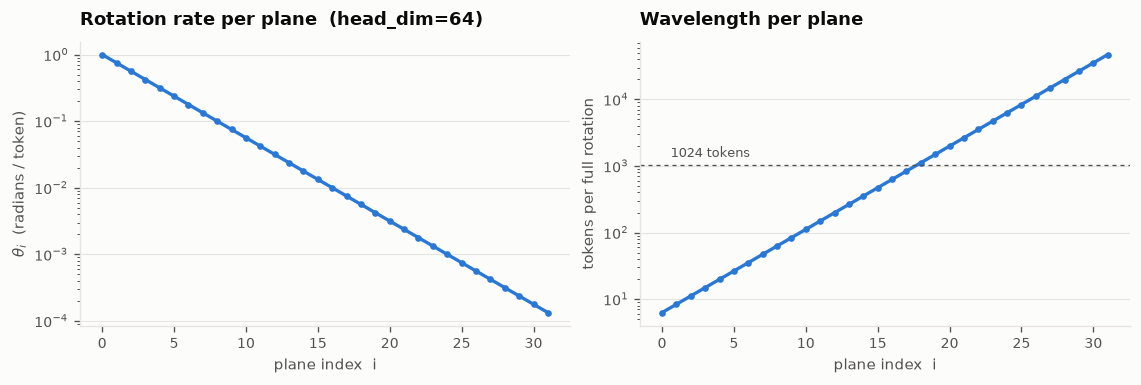

fastest plane: one full turn every 6.3 tokens
slowest plane: one full turn every 47,117 tokens


In [10]:
head_dim = 64
theta = R.rope_frequencies(head_dim)
wavelength = 2 * math.pi / theta

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.1), constrained_layout=True)
a1.plot(range(len(theta)), theta, color=PE_COLOR["rope"], marker="o", markersize=3)
a1.set_yscale("log")
a1.set(title=f"Rotation rate per plane  (head_dim={head_dim})",
       xlabel="plane index  i", ylabel=r"$\theta_i$  (radians / token)")

a2.plot(range(len(theta)), wavelength, color=PE_COLOR["rope"], marker="o", markersize=3)
a2.set_yscale("log")
a2.axhline(1024, color=INK_2, lw=0.8, ls=(0, (3, 3)))
a2.annotate("1024 tokens", (0.6, 1024), textcoords="offset points", xytext=(0, 5),
            fontsize=8, color=INK_2)
a2.set(title="Wavelength per plane", xlabel="plane index  i",
       ylabel="tokens per full rotation")
plt.show()

print(f"fastest plane: one full turn every {wavelength[0]:.1f} tokens")
print(f"slowest plane: one full turn every {wavelength[-1]:,.0f} tokens")

### The matrix is 99.6% zeros — so never build it

$R^d_{\Theta,m}$ is $d\times d$ but has only $2d$ non-zeros. Materialising it would turn
an $O(d)$ operation into $O(d^2)$. Paper eq. (34) gives the elementwise form instead:

$$R_{\Theta,m}^{d}\boldsymbol x =
\begin{pmatrix}x_1\\x_2\\x_3\\x_4\\\vdots\end{pmatrix}\odot
\begin{pmatrix}\cos m\theta_1\\\cos m\theta_1\\\cos m\theta_2\\\cos m\theta_2\\\vdots\end{pmatrix}
+
\begin{pmatrix}-x_2\\x_1\\-x_4\\x_3\\\vdots\end{pmatrix}\odot
\begin{pmatrix}\sin m\theta_1\\\sin m\theta_1\\\sin m\theta_2\\\sin m\theta_2\\\vdots\end{pmatrix}$$

Two multiplies and an add — that is the whole implementation.

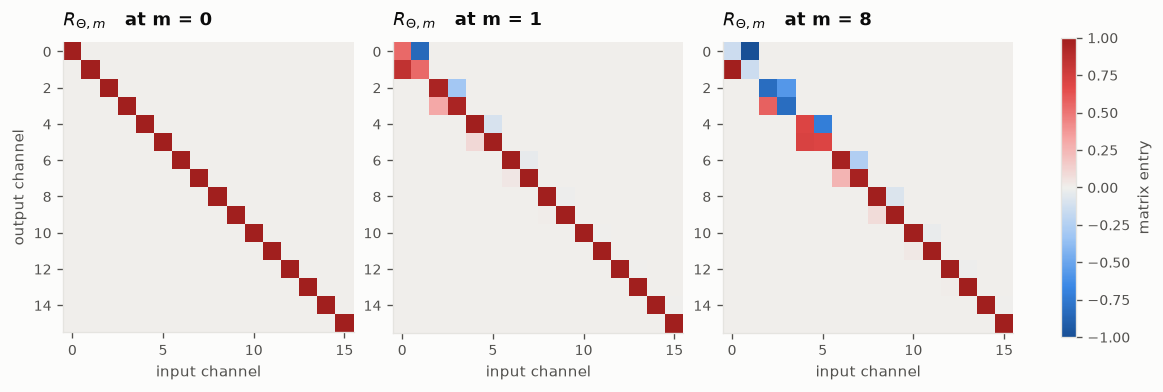

64x64 rotation matrix: 128 non-zeros out of 4096 (3.1% dense)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2), constrained_layout=True)
for ax, pos in zip(axes, [0, 1, 8]):
    m = R.rope_matrix(pos, 16)
    im = ax.imshow(m, cmap=DIV, norm=TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1),
                   interpolation="nearest")
    ax.set(title=f"$R_{{\\Theta,m}}$   at m = {pos}", xlabel="input channel")
    ax.grid(False)
    if ax is axes[0]:
        ax.set_ylabel("output channel")
fig.colorbar(im, ax=axes, shrink=0.82, label="matrix entry")
plt.show()

m = R.rope_matrix(8, 64)
print(f"64x64 rotation matrix: {int((m != 0).sum())} non-zeros out of {m.numel()} "
      f"({(m != 0).float().mean():.1%} dense)")

`m = 0` is the identity — position 0 is unrotated, which is why RoPE needs no special
casing at the start of a sequence. Larger `m` tilts each 2×2 block further, the top-left
blocks (fast planes) fastest.

### Writing it from scratch, in 8 lines

Below is the implementation in full, followed by a check against `rope.py` so the
notebook and the library can never silently drift apart.

In [12]:
def my_rope_cache(head_dim, seq_len, base=10000.0):
    # cos/sin lookup tables, shape (seq_len, head_dim)
    theta = base ** (-torch.arange(0, head_dim, 2).float() / head_dim)   # (d/2,)
    angles = torch.outer(torch.arange(seq_len).float(), theta)           # (T, d/2)
    angles = torch.cat([angles, angles], dim=-1)                         # (T, d)
    return angles.cos(), angles.sin()

def my_rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2, x1], dim=-1)                                  # (x1,x2) -> (-x2,x1)

def my_apply_rope(x, cos, sin, offset=0):
    # x: (batch, heads, T, head_dim)
    t = x.shape[-2]
    return x * cos[offset:offset + t] + my_rotate_half(x) * sin[offset:offset + t]

# --- agreement with rope.py, and with the dense matrix form -----------------
g = torch.Generator().manual_seed(3)
x = torch.randn(2, 4, 32, 64, generator=g)
mine = my_apply_rope(x, *my_rope_cache(64, 32))
lib  = R.apply_rope(x, *R.rope_cache(64, 32))
print("notebook == rope.py :", torch.allclose(mine, lib, atol=1e-6))

x1 = torch.randn(1, 1, 12, 16, generator=g)
fast = R.apply_rope_interleaved(x1, *R.rope_cache_interleaved(16, 12))[0, 0]
slow = torch.stack([R.rope_matrix(p, 16) @ x1[0, 0, p] for p in range(12)])
print("elementwise == dense R:", torch.allclose(fast, slow, atol=1e-5))

notebook == rope.py : True
elementwise == dense R: True


### Why `rotate_half` and not the paper's interleaving?

The paper pairs channels as $(x_1,x_2), (x_3,x_4), \dots$ — adjacent. Hugging Face,
LLaMA and GPT-NeoX pair $(x_1, x_{1+d/2}), (x_2, x_{2+d/2}), \dots$ — split down the
middle, which is one `chunk` + one `cat` instead of a strided reshape.

The two differ only by a fixed permutation of channels. Since $W_q$ and $W_k$ are
learned, that permutation is absorbed during training: **the choice is a convention,
not a difference in the method.** The property that matters holds either way.

In [13]:
g = torch.Generator().manual_seed(4)
q, k = (torch.randn(1, 2, 24, 32, generator=g) for _ in range(2))

rows = []
for name, cache, apply in [("interleaved (paper / GPT-J)", R.rope_cache_interleaved, R.apply_rope_interleaved),
                           ("half-split (HF / LLaMA)",     R.rope_cache,             R.apply_rope)]:
    cos, sin = cache(32, 256)
    base  = apply(q, cos, sin, 0)  @ apply(k, cos, sin, 0).transpose(-1, -2)
    moved = apply(q, cos, sin, 50) @ apply(k, cos, sin, 50).transpose(-1, -2)
    rows.append({"pairing": name,
                 "max |logit| drift after shifting 50": (base - moved).abs().max().item(),
                 "norm of q preserved": torch.allclose(apply(q, cos, sin).norm(dim=-1),
                                                       q.norm(dim=-1), atol=1e-5)})
show_table(pd.DataFrame(rows).set_index("pairing"), "Both pairings satisfy the requirement")

,max |logit| drift after shifting 50,norm of q preserved
pairing,,
interleaved (paper / GPT-J),0.000,True
half-split (HF / LLaMA),0.000,True


**Answer to Q4.** Rotate $d/2$ planes at geometrically spaced rates. Conceptually it is
a $d\times d$ block-diagonal orthogonal matrix; in code it is `x*cos + rotate_half(x)*sin`
— $O(d)$ work, zero learned parameters, and applied to $q$ and $k$ only (never to $v$,
never to the residual stream).

---
## Q5 — Does RoPE really make attention depend on $m-n$ only?

Q2's table already showed zero drift for RoPE. Here is the same claim as a picture: the
full $T\times T$ logit matrix for the *same* tokens placed at two different absolute
offsets, RoPE against sinusoidal absolute PE.

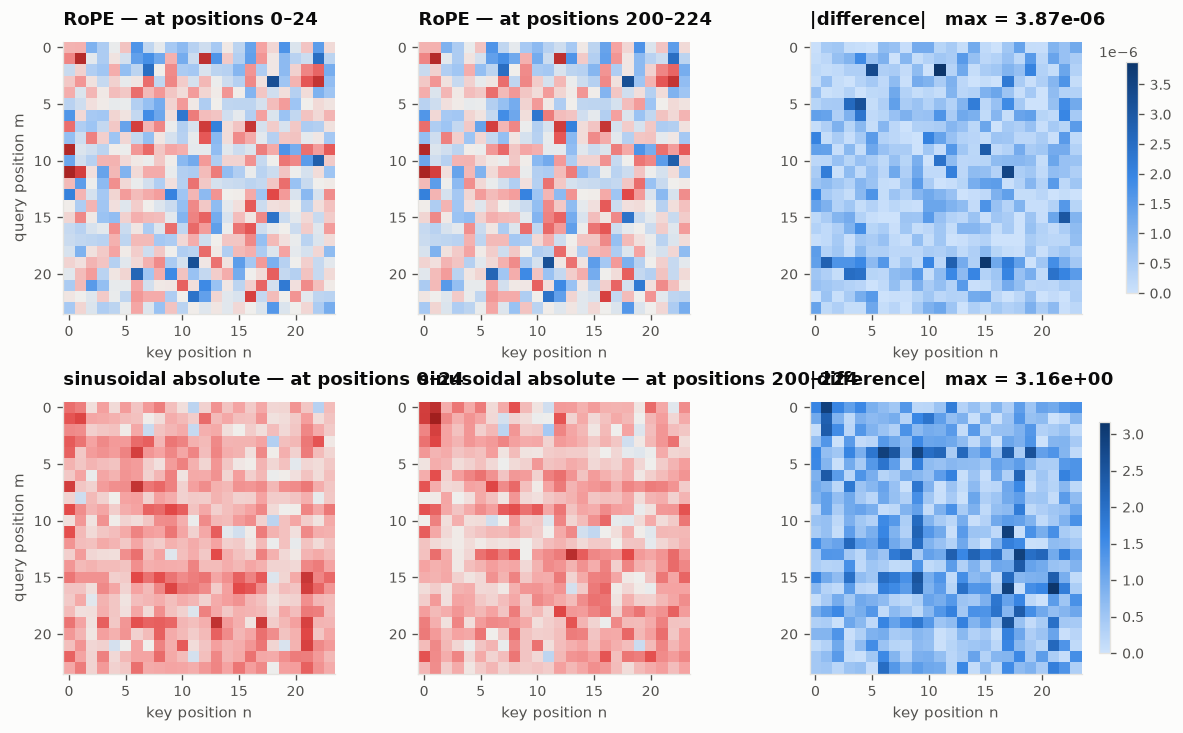

In [14]:
g = torch.Generator().manual_seed(5)
d_head, t = 32, 24
q0, k0 = torch.randn(t, d_head, generator=g), torch.randn(t, d_head, generator=g)
cos, sin = R.rope_cache(d_head, 512)
pe = R.sinusoidal_pe(512, d_head)

def logits(kind, offset):
    if kind == "rope":
        qq = R.apply_rope(q0.unsqueeze(0), cos, sin, offset)[0]
        kk = R.apply_rope(k0.unsqueeze(0), cos, sin, offset)[0]
    else:
        qq, kk = q0 + pe[offset:offset + t], k0 + pe[offset:offset + t]
    return (qq @ kk.T / math.sqrt(d_head)).numpy()

OFFS = (0, 200)
fig, axes = plt.subplots(2, 3, figsize=(9.8, 6.0), constrained_layout=True)
for row, kind in enumerate(["rope", "sinusoidal"]):
    a, b = logits(kind, OFFS[0]), logits(kind, OFFS[1])
    lim = max(abs(a).max(), abs(b).max())
    for col, (mat, ttl) in enumerate([(a, f"at positions {OFFS[0]}–{OFFS[0]+t}"),
                                      (b, f"at positions {OFFS[1]}–{OFFS[1]+t}")]):
        im = axes[row, col].imshow(mat, cmap=DIV, norm=TwoSlopeNorm(0, -lim, lim))
        axes[row, col].set_title(f"{PE_LABEL[kind]} — {ttl}")
    dif = np.abs(a - b)
    im2 = axes[row, 2].imshow(dif, cmap=SEQ, vmin=0, vmax=max(1e-12, dif.max()))
    axes[row, 2].set_title(f"|difference|   max = {dif.max():.2e}")
    fig.colorbar(im2, ax=axes[row, 2], shrink=0.85)
    for ax in axes[row]:
        ax.grid(False)
        ax.set_xlabel("key position n")
    axes[row, 0].set_ylabel("query position m")
plt.show()

Top row: RoPE's two logit matrices are identical to machine precision, and the diagonal
band structure makes the relative dependence visible — the value at $(m,n)$ is a function
of $m-n$, so it is constant along each diagonal. Bottom row: the absolute-PE matrices are
visibly different objects, with a difference on the order of the logits themselves.

**Answer to Q5.** Yes, and exactly, not approximately. Translating a block of tokens
anywhere in the sequence leaves every RoPE logit unchanged, because the two absolute
phases cancel inside the dot product. This is the property that makes the *contents* of
a pattern, rather than its location, what the model learns.

---
## Q6 — Does attention decay as tokens get further apart?

A useful prior for language: all else equal, distant tokens should matter less. §3.4.3
of the paper argues RoPE has this built in. Writing the logit as a sum over planes and
applying Abel summation gives a bound governed by

$$\frac{1}{d/2}\sum_{i}\Big|\sum_{j\le i} e^{\,\mathrm{i}\,(m-n)\theta_j}\Big|$$

which is the quantity plotted in the paper's figure 2. Because the $\theta_j$ are
geometrically spaced, those unit phasors line up at distance 0 and progressively
decohere as the distance grows — so the bound falls.

We plot the paper's bound *and* a direct measurement — with one caveat worth stating,
because it is easy to fake this result. If $q$ and $k$ are drawn independently from an
isotropic Gaussian, then $\mathbb E\,|\langle q, R_n k\rangle|$ is **identical for every
$n$**: a rotation cannot change an isotropic distribution, so there is no decay to
measure there. What decays is the logit between a query and a key that *match in
content* — precisely the case where an attention head fires. Both are plotted, and the
oscillation is real (the raw curve is drawn faintly, with a rolling mean over it).

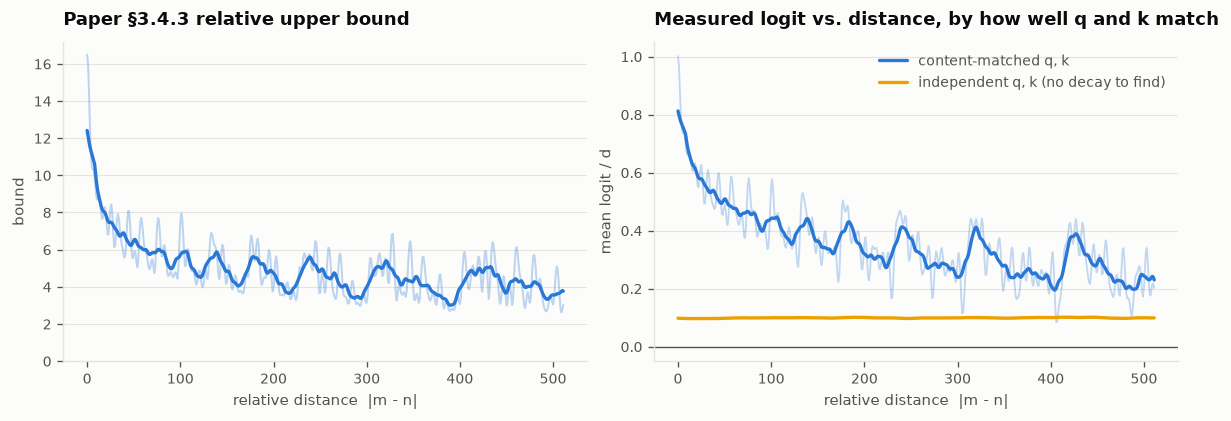

,paper bound,"logit, k = q","logit, k = q + noise","|logit|, independent q,k"
relative distance,,,,
0,16.500,1.001,1.003,0.098
16,7.650,0.605,0.604,0.097
64,5.700,0.434,0.431,0.100
256,3.844,0.356,0.354,0.098


In [15]:
head_dim, max_dist = 64, 512
dist, bound = R.relative_upper_bound(head_dim, max_dist)

# An empirical view. Note *which* logit we have to measure: for q and k drawn
# independently from an isotropic Gaussian, E|<q, R_n k>| is the SAME for every n -
# a rotation cannot change an isotropic distribution. The quantity that decays is the
# logit of a query and key that actually *match in content*, which is the case where
# attention fires. So we measure aligned pairs (k = q) and near-aligned ones.
g = torch.Generator().manual_seed(6)
n_samples = 2048
qs = torch.randn(n_samples, head_dim, generator=g)
cos, sin = R.rope_cache(head_dim, max_dist)

curves = {}
for name, noise in [("k = q  (identical content)", 0.0), ("k = q + noise  (similar)", 1.0)]:
    ks = qs + noise * torch.randn(n_samples, head_dim, generator=g)
    vals = []
    for n in range(max_dist):
        # <R_m q, R_n k> depends only on n - m, so rotating the key alone by the gap
        # is the same measurement with m = 0
        kk = R.apply_rope(ks.unsqueeze(1), cos, sin, offset=n)[:, 0]
        vals.append(((qs * kk).sum(-1) / head_dim).mean().item())
    curves[name] = np.array(vals)

indep = []
ks_indep = torch.randn(n_samples, head_dim, generator=g)
for n in range(max_dist):
    kk = R.apply_rope(ks_indep.unsqueeze(1), cos, sin, offset=n)[:, 0]
    indep.append(((qs * kk).sum(-1) / head_dim).abs().mean().item())
indep = np.array(indep)

def trend(y, w=17):
    # rolling mean, so the underlying decay is readable through the oscillation
    return pd.Series(y).rolling(w, center=True, min_periods=1).mean().values

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.8, 3.4), constrained_layout=True)

a1.plot(dist, bound, color=PE_COLOR["rope"], alpha=0.30, lw=1.2)
a1.plot(dist, trend(bound.numpy()), color=PE_COLOR["rope"], label="rolling mean")
a1.set(title="Paper §3.4.3 relative upper bound", xlabel="relative distance  |m - n|",
       ylabel="bound", ylim=(0, None))

# the k = q and k = q + noise curves coincide almost exactly, so drawing both would
# just hide one behind the other - the table below carries both
y_matched = curves["k = q  (identical content)"]
a2.plot(np.arange(max_dist), y_matched, color=PE_COLOR["rope"], alpha=0.28, lw=1.1)
a2.plot(np.arange(max_dist), trend(y_matched), color=PE_COLOR["rope"],
        label="content-matched q, k")
a2.plot(np.arange(max_dist), trend(indep), color=PE_COLOR["none"],
        label="independent q, k (no decay to find)")
a2.axhline(0, color=INK_2, lw=0.8)
a2.set(title="Measured logit vs. distance, by how well q and k match",
       xlabel="relative distance  |m - n|", ylabel="mean logit / d")
a2.legend(loc="upper right")
plt.show()

summary = pd.DataFrame({
    "paper bound": [bound[n].item() for n in [0, 16, 64, 256]],
    "logit, k = q": [curves["k = q  (identical content)"][n] for n in [0, 16, 64, 256]],
    "logit, k = q + noise": [curves["k = q + noise  (similar)"][n] for n in [0, 16, 64, 256]],
    "|logit|, independent q,k": [indep[n] for n in [0, 16, 64, 256]],
}, index=pd.Index([0, 16, 64, 256], name="relative distance"))
show_table(summary, "Content-matched attention decays; the isotropic case has nothing to decay")

### The base $\theta$ is the knob that sets the decay length

$\theta_i = b^{-2i/d}$ with $b = 10000$ in the paper. Shrink $b$ and every plane spins
faster, so phases decohere sooner and attention becomes short-sighted; grow $b$ and the
useful range stretches. This single constant is what long-context methods (NTK-aware
scaling, YaRN, LLaMA-3's $b=500000$) reach for.

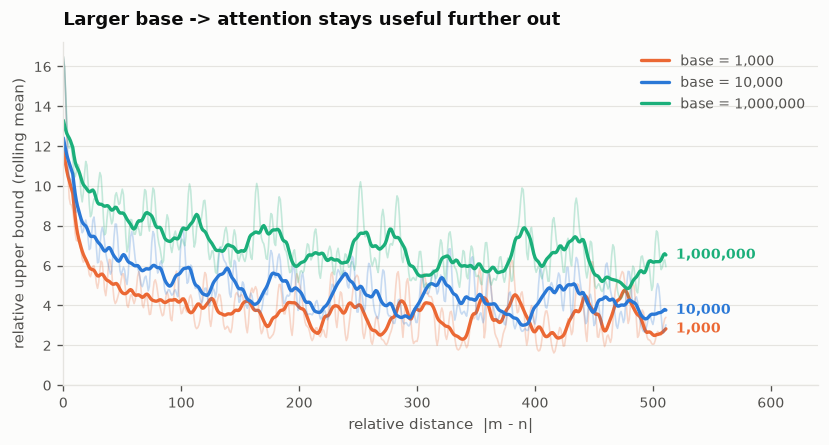

In [16]:
fig, ax = plt.subplots(figsize=(6.8, 3.6), constrained_layout=True)
bases = [(1e3, PE_COLOR["learned"]), (1e4, PE_COLOR["rope"]), (1e6, PE_COLOR["sinusoidal"])]
ends = []
for b, colr in bases:
    d_, bd = R.relative_upper_bound(64, 512, base=b)
    sm = trend(bd.numpy())
    ax.plot(d_, bd, color=colr, alpha=0.25, lw=1.0)
    ax.plot(d_, sm, color=colr, label=f"base = {b:,.0f}")
    ends.append((d_[-1].item(), sm[-1], f"{b:,.0f}", colr))
ax.set(title="Larger base -> attention stays useful further out",
       xlabel="relative distance  |m - n|", ylabel="relative upper bound (rolling mean)",
       xlim=(0, 640), ylim=(0, None))
ax.legend(loc="upper right")
label_ends(ax, ends)
plt.show()

**Answer to Q6.** Yes — long-term decay is a consequence of the geometric spacing of the
$\theta_i$, not an extra mechanism. The paper's bound falls in trend with distance, and so does the
logit between content-matched $q,k$ — which decays from its maximum toward zero as the
planes decohere. For content-*unrelated* $q,k$ there is nothing to decay, and the flat
yellow line says so honestly. The base $\theta$ sets how fast the decay happens.

---
## Q7 — Does any of this help a model that actually has to learn something?

Properties are only interesting if they show up in training. We need a task that is
**solvable from relative position alone**, so that the encoding is the thing being
tested rather than the model's capacity.

### The task: offset copy

```
[PAD]×offset   s₁ s₂ … s_L   <SEP>   s₁ s₂ … s_L
|--- shift ---||-- prompt --|       |--- target --|
```

To emit $s_i$ after the separator, a query must attend to the slot exactly $L+1$ tokens
to its left. Nothing else in the sequence tells it what to copy. The `offset` slides the
whole pattern to a different absolute location **while leaving every relative distance
identical** — so it separates "learned the pattern" from "memorised where the pattern was".

Train at offsets 0–4. Test at offsets far outside that range.

In [17]:
x, y = T.make_batch(1, length=8, offset=3, generator=torch.Generator().manual_seed(7))
sym = lambda v: "PAD" if v == T.PAD else ("SEP" if v == T.SEP else str(int(v)))
print("input :", " ".join(f"{sym(v):>4}" for v in x[0]))
print("target:", " ".join(f"{'  . ' if v == T.IGNORE else f'{int(v):>4}'}" for v in y[0]))
print("\n'.' = position not scored. Only the copy span counts towards the loss.")

input :  PAD  PAD  PAD   15   12    1    6    3    7    7   19  SEP   15   12    1    6    3    7    7   19
target:   .    .    .    .    .    .    .    .    .    .    .    15   12    1    6    3    7    7   19   . 

'.' = position not scored. Only the copy span counts towards the loss.


In [18]:
CFG = dict(d_model=128, n_heads=4, n_layers=3, max_len=256)
STEPS, LENGTH = 1000, 16

models, history = {}, {}
for mode in R.POS_MODES:
    torch.manual_seed(0)                       # identical init and data order per run
    m = R.TinyTransformer(T.VOCAB_SIZE, pos_mode=mode, **CFG).to(DEVICE)
    print(f"\n{PE_LABEL[mode]}  ({sum(p.numel() for p in m.parameters()):,} params)")
    history[mode] = T.train(m, steps=STEPS, length=LENGTH, max_train_offset=4,
                            device=DEVICE, log_every=250)
    models[mode] = m


no position encoding  (599,168 params)

    step   250  train loss 1.9230   val acc 32.03%   [  3.3s]


    step   500  train loss 1.3598   val acc 55.42%   [  5.4s]


    step   750  train loss 0.7680   val acc 73.34%   [  7.7s]


    step  1000  train loss 0.2058   val acc 87.28%   [  9.8s]

learned absolute  (631,936 params)


...

    step  1000  train loss 0.0011   val acc 100.00%   [  8.5s]

RoPE  (599,168 params)


    step   250  train loss 0.0077   val acc 100.00%   [  2.6s]


    step   500  train loss 0.0014   val acc 100.00%   [  5.2s]


    step   750  train loss 0.0008   val acc 100.00%   [  7.8s]


    step  1000  train loss 0.0007   val acc 100.00%   [ 10.4s]


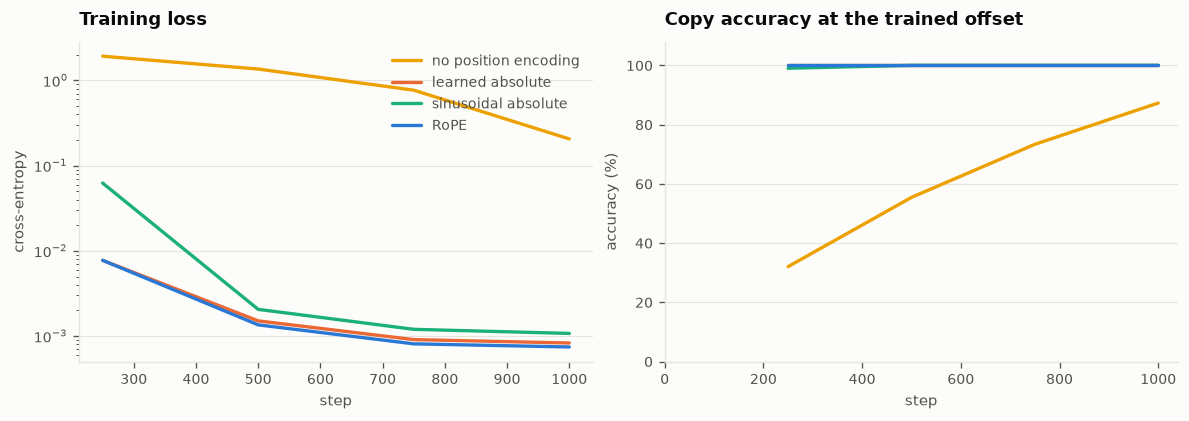

In [19]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.8, 3.4), constrained_layout=True)
for mode in R.POS_MODES:
    steps = [h[0] for h in history[mode]]
    a1.plot(steps, [h[1] for h in history[mode]], color=PE_COLOR[mode], label=PE_LABEL[mode])
    a2.plot(steps, [h[2] * 100 for h in history[mode]], color=PE_COLOR[mode])
a1.set(title="Training loss", xlabel="step", ylabel="cross-entropy", yscale="log")
a2.set(title="Copy accuracy at the trained offset", xlabel="step",
       ylabel="accuracy (%)", ylim=(0, 108), xlim=(0, STEPS * 1.04))
a1.legend(loc="upper right")   # three of the four lines sit on 100%, so the legend
plt.show()                     # carries identity for both panels

At the offsets they were trained on, the three position-aware encodings all solve the
task; the no-position model cannot (causal masking leaks a little order information,
which is why it gets some way above chance but stalls).

Now the interesting measurement — **the same task, the same relative distances, moved to
absolute positions the models never saw.**

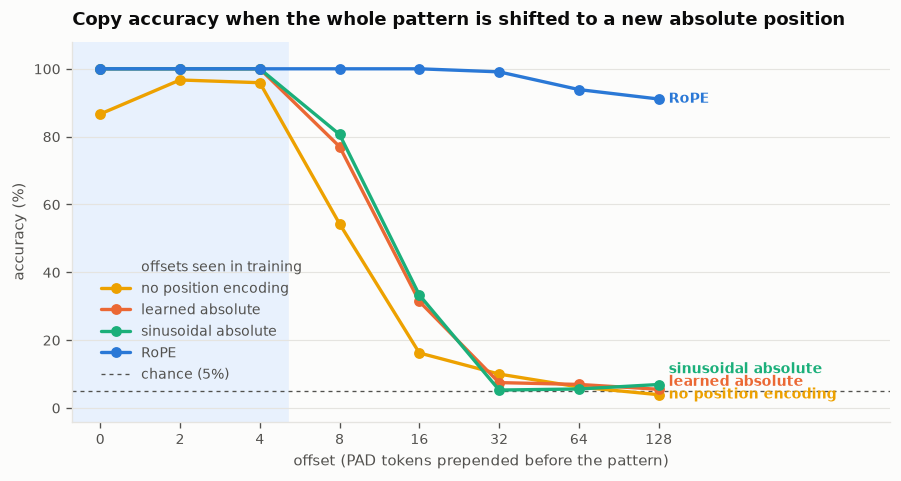

,no position encoding,learned absolute,sinusoidal absolute,RoPE
offset,,,,
0,86.700,100.000,100.000,100.000
2,96.700,100.000,100.000,100.000
4,95.900,100.000,100.000,100.000
8,54.300,77.100,80.600,100.000
16,16.200,31.400,33.300,100.000
32,10.000,7.500,5.300,99.100
64,6.200,6.900,5.600,93.900
128,3.900,5.500,6.900,91.100


In [20]:
OFFSETS = [0, 2, 4, 8, 16, 32, 64, 128]
acc = {mode: [T.evaluate(models[mode], length=LENGTH, offset=o, seed=99, device=DEVICE)[0] * 100
              for o in OFFSETS] for mode in R.POS_MODES}

xs = np.arange(len(OFFSETS))                      # equal spacing: this axis is ordinal
trained_hi = max(i for i, o in enumerate(OFFSETS) if o <= 4)

fig, ax = plt.subplots(figsize=(7.4, 3.9), constrained_layout=True)
ax.axvspan(-0.35, trained_hi + 0.35, color="#e8f1fd", zorder=0,
           label="offsets seen in training")
ends = []
for mode in R.POS_MODES:
    ax.plot(xs, acc[mode], color=PE_COLOR[mode], marker="o", label=PE_LABEL[mode],
            zorder=3)
    ends.append((xs[-1], acc[mode][-1], PE_LABEL[mode], PE_COLOR[mode]))
ax.axhline(100 / T.N_SYMBOLS, color=INK_2, lw=0.8, ls=(0, (3, 3)), zorder=2,
           label=f"chance ({100 / T.N_SYMBOLS:.0f}%)")
ax.set(title="Copy accuracy when the whole pattern is shifted to a new absolute position",
       xlabel="offset (PAD tokens prepended before the pattern)", ylabel="accuracy (%)",
       xlim=(-0.35, len(OFFSETS) + 1.9), ylim=(-4, 108))
ax.set_xticks(xs, [str(o) for o in OFFSETS])
ax.legend(loc="lower left", bbox_to_anchor=(0.02, 0.07))
label_ends(ax, ends, min_gap=12)
plt.show()

show_table(pd.DataFrame(acc, index=pd.Index(OFFSETS, name="offset"))
             .rename(columns=PE_LABEL).round(1),
           "Accuracy (%) by shift of the pattern - trained only at offsets 0-4")

**Answer to Q7.** Yes, and the gap is not subtle. Every position-aware model learns the
task at the offsets it saw. Move the identical pattern elsewhere and both absolute
encodings collapse toward chance — they had bound the solution to specific absolute
slots — while RoPE is flat, because as Q5 established its logits never depended on the
absolute location in the first place. The property is not decoration; it is what the
model generalises with.

---
## Q8 — Does it survive linear attention, where relative biases cannot go?

§3.3. Linear attention replaces softmax with a kernel feature map $\phi$ and reassociates:

$$\text{Attention}(Q,K,V)_m = \frac{\phi(\boldsymbol q_m)^\top \sum_n \phi(\boldsymbol k_n)\boldsymbol v_n^\top}{\phi(\boldsymbol q_m)^\top\sum_n \phi(\boldsymbol k_n)}$$

The $T\times T$ logit matrix is never formed, so an additive $b_{m-n}$ has nowhere to be
added — its whole formulation presumes that matrix exists. A rotation has no such
problem: it is applied to $q$ and $k$ *before* they enter the sum, so it costs nothing
structurally.

$$\text{Attention}_m = \frac{\sum_n \big(R_{\Theta,m}\phi(\boldsymbol q_m)\big)^\top\big(R_{\Theta,n}\phi(\boldsymbol k_n)\big)\boldsymbol v_n}{\sum_n \phi(\boldsymbol q_m)^\top \phi(\boldsymbol k_n)}$$

(The paper keeps the denominator un-rotated so it stays positive — a rotated inner
product can be negative, which would make the normaliser meaningless.)

In [21]:
g = torch.Generator().manual_seed(8)
b, h, t, d = 1, 2, 32, 32
q, k, v = (torch.randn(b, h, t, d, generator=g) for _ in range(3))
cos, sin = R.rope_cache(d, 512)

plain = R.linear_attention_rope(q, k, v)
roped = R.linear_attention_rope(q, k, v, cos, sin)
print("linear attention, no RoPE   -> output shape", tuple(plain.shape))
print("linear attention, with RoPE -> output shape", tuple(roped.shape))
print("RoPE changed the output     :", not torch.allclose(plain, roped, atol=1e-4))

# and the numerator's relative property survives the feature map
qq, kk = F.elu(q) + 1, F.elu(k) + 1
num = lambda off: (R.apply_rope(qq, cos, sin, off) @
                   R.apply_rope(kk, cos, sin, off).transpose(-1, -2))
print("shift-invariant numerator   :",
      f"max drift {(num(0) - num(77)).abs().max().item():.2e}")

cost = pd.DataFrame({
    "builds a T x T logit matrix": {"softmax + relative bias": True, "softmax + RoPE": True,
                                    "linear attention + relative bias": False,
                                    "linear attention + RoPE": False},
    "position mechanism usable": {"softmax + relative bias": True, "softmax + RoPE": True,
                                  "linear attention + relative bias": False,
                                  "linear attention + RoPE": True},
    "extra learned parameters": {"softmax + relative bias": "O(max_dist x heads)",
                                 "softmax + RoPE": "none",
                                 "linear attention + relative bias": "n/a",
                                 "linear attention + RoPE": "none"},
})
show_table(cost, "Why RoPE composes where an additive relative bias does not")

linear attention, no RoPE   -> output shape (1, 2, 32, 32)
linear attention, with RoPE -> output shape (1, 2, 32, 32)
RoPE changed the output     : True
shift-invariant numerator   : max drift 4.48e-05


,builds a T x T logit matrix,position mechanism usable,extra learned parameters
softmax + relative bias,True,True,O(max_dist x heads)
softmax + RoPE,True,True,none
linear attention + relative bias,False,False,n/a
linear attention + RoPE,False,True,none


**Answer to Q8.** Yes. Because RoPE is a transformation *of* $q$ and $k$ rather than a
term added *to* the logits, it is agnostic to how the logits are subsequently computed —
including by machinery that never computes them explicitly. That composability is the
practical reason RoPE, and not relative bias, became the default.

---
## Appendix A — the paper's mathematics, equation by equation

Everything above was motivated. This appendix is the *audit*: each numbered equation
from the paper, transcribed into one cell of PyTorch, with a check that the code and the
formula agree. Symbols follow the paper: $\boldsymbol x_m$ is the embedding at position
$m$, $\boldsymbol q_m = f_q(\boldsymbol x_m, m)$, $\boldsymbol k_n = f_k(\boldsymbol x_n, n)$,
$d$ is the head dimension.

### Eq. (1)–(4) — the attention we are modifying

$$\boldsymbol q_m = W_q \boldsymbol x_m,\quad \boldsymbol k_n = W_k \boldsymbol x_n,\quad \boldsymbol v_n = W_v \boldsymbol x_n$$
$$a_{m,n} = \frac{\exp\!\big(\boldsymbol q_m^\top \boldsymbol k_n / \sqrt d\big)}{\sum_{j} \exp\!\big(\boldsymbol q_m^\top \boldsymbol k_j / \sqrt d\big)}, \qquad
\boldsymbol o_m = \sum_n a_{m,n}\boldsymbol v_n$$

In [22]:
g = torch.Generator().manual_seed(20)
d, t = 16, 6
X = torch.randn(t, d, generator=g)
Wq_, Wk_, Wv_ = (torch.randn(d, d, generator=g) / math.sqrt(d) for _ in range(3))

def eq1_4(X, Wq_, Wk_, Wv_):
    q, k, v = X @ Wq_.T, X @ Wk_.T, X @ Wv_.T          # eq. 1-3
    a = torch.softmax(q @ k.T / math.sqrt(X.shape[-1]), dim=-1)
    return a @ v, a                                    # eq. 4

o, a = eq1_4(X, Wq_, Wk_, Wv_)
print("attention rows sum to 1:", torch.allclose(a.sum(-1), torch.ones(t), atol=1e-6))
print("matches torch reference :", torch.allclose(
    o, F.scaled_dot_product_attention(X @ Wq_.T, X @ Wk_.T, X @ Wv_.T), atol=1e-5))

attention rows sum to 1: True
matches torch reference : True


### Eq. (5)–(6) — the 2017 baseline: sinusoidal absolute PE

$$f_{t:t\in\{q,k,v\}}(\boldsymbol x_i, i) = W_{t}(\boldsymbol x_i + \boldsymbol p_i),\qquad
\boldsymbol p_{i,2t}=\sin\!\frac{i}{10000^{2t/d}},\quad \boldsymbol p_{i,2t+1}=\cos\!\frac{i}{10000^{2t/d}}$$

In [23]:
def eq5_6(seq_len, d):
    p = torch.zeros(seq_len, d)
    for i in range(seq_len):
        for tt in range(d // 2):
            w = 1.0 / (10000 ** (2 * tt / d))
            p[i, 2 * tt]     = math.sin(i * w)
            p[i, 2 * tt + 1] = math.cos(i * w)
    return p

print("literal transcription == rope.sinusoidal_pe:",
      torch.allclose(eq5_6(64, 32), R.sinusoidal_pe(64, 32), atol=1e-6))

literal transcription == rope.sinusoidal_pe: True


### Eq. (11) — the requirement RoPE has to satisfy

$$\langle f_q(\boldsymbol x_m, m), f_k(\boldsymbol x_n, n)\rangle = g(\boldsymbol x_m, \boldsymbol x_n, m-n)$$

Turned into a test: if the left side truly equals a function of $m-n$, then any two
$(m,n)$ pairs with the same difference must give the same number.

In [24]:
def satisfies_eq11(f, m, n, m2, n2, q_raw, k_raw, tol=1e-4):
    lhs  = (f(q_raw, m)  * f(k_raw, n)).sum(-1)
    lhs2 = (f(q_raw, m2) * f(k_raw, n2)).sum(-1)
    return (lhs - lhs2).abs().max().item()

g = torch.Generator().manual_seed(21)
d = 32
qr, kr = torch.randn(8, d, generator=g), torch.randn(8, d, generator=g)
cos, sin = R.rope_cache(d, 1024)
f_rope = lambda x, p: R.apply_rope(x.unsqueeze(0), cos, sin, p)[0]
f_abs  = lambda x, p: x + R.sinusoidal_pe(1024, d)[p:p + x.shape[0]]

check = pd.DataFrame([
    {"f": "RoPE",        "(m,n) = (5,2) vs (105,102)":  satisfies_eq11(f_rope, 5, 2, 105, 102, qr, kr)},
    {"f": "absolute PE", "(m,n) = (5,2) vs (105,102)":  satisfies_eq11(f_abs,  5, 2, 105, 102, qr, kr)},
]).set_index("f")
show_table(check, "Residual of eq. (11): 0 means the requirement holds")

,"(m,n) = (5,2) vs (105,102)"
f,
RoPE,0.000
absolute PE,9.546


### Eq. (12)–(13) — the 2-D solution

$$f_q(\boldsymbol x_m,m) = (W_q\boldsymbol x_m)e^{im\theta},\qquad f_k(\boldsymbol x_n,n) = (W_k\boldsymbol x_n)e^{in\theta}$$

$$f_{\{q,k\}}(\boldsymbol x_m,m) = \begin{pmatrix}\cos m\theta & -\sin m\theta\\ \sin m\theta & \cos m\theta\end{pmatrix}\begin{pmatrix}W^{(11)} & W^{(12)}\\ W^{(21)} & W^{(22)}\end{pmatrix}\begin{pmatrix}x_m^{(1)}\\ x_m^{(2)}\end{pmatrix}$$

In [25]:
theta0 = 0.37
def eq12_complex(x2, pos):                     # x2: (..., 2) real -> complex rotate
    z = torch.view_as_complex(x2.contiguous())
    return torch.view_as_real(z * complex(math.cos(pos * theta0), math.sin(pos * theta0)))

def eq13_matrix(x2, pos):                      # the same thing as a 2x2 matrix
    c, s = math.cos(pos * theta0), math.sin(pos * theta0)
    Rm = torch.tensor([[c, -s], [s, c]])
    return x2 @ Rm.T

g = torch.Generator().manual_seed(22)
v2 = torch.randn(5, 2, generator=g)
print("eq.12 (complex) == eq.13 (matrix):",
      torch.allclose(eq12_complex(v2, 9), eq13_matrix(v2, 9), atol=1e-6))

eq.12 (complex) == eq.13 (matrix): True


### Eq. (14) — the resulting $g$, and why the phases subtract

$$g(\boldsymbol x_m, \boldsymbol x_n, m-n) = \operatorname{Re}\!\big[(W_q\boldsymbol x_m)\overline{(W_k\boldsymbol x_n)}\,e^{i(m-n)\theta}\big]$$

In [26]:
g_ = torch.Generator().manual_seed(23)
qz = torch.view_as_complex(torch.randn(4, 2, generator=g_))
kz = torch.view_as_complex(torch.randn(4, 2, generator=g_))

def lhs_eq14(m, n):        # <f_q, f_k> computed honestly, from absolute m and n
    fq = torch.view_as_real(qz * complex(math.cos(m * theta0), math.sin(m * theta0)))
    fk = torch.view_as_real(kz * complex(math.cos(n * theta0), math.sin(n * theta0)))
    return (fq * fk).sum(-1)

def rhs_eq14(m, n):        # g(...), which only ever sees m - n
    rel = complex(math.cos((m - n) * theta0), math.sin((m - n) * theta0))
    return (qz * torch.conj(kz) * rel).real

pairs = [(9, 4), (109, 104), (4, 9)]
print("m    n   m-n   max |LHS - RHS|")
for m, n in pairs:
    print(f"{m:<4} {n:<3} {m-n:<5} {(lhs_eq14(m, n) - rhs_eq14(m, n)).abs().max().item():.2e}")
print("\nAnd the value itself only depends on m-n:")
print("  g at (9,4)   =", rhs_eq14(9, 4)[0].item())
print("  g at (109,104)=", rhs_eq14(109, 104)[0].item())

m    n   m-n   max |LHS - RHS|
9    4   5     0.00e+00
109  104 5     1.19e-07
4    9   -5    5.96e-08

And the value itself only depends on m-n:
  g at (9,4)   = 1.31321120262146
  g at (109,104)= 1.31321120262146


### Eq. (15) — the $d$-dimensional rotation

$$R^{d}_{\Theta,m} = \operatorname{diag}\!\Big(R(m\theta_1),\dots,R(m\theta_{d/2})\Big),
\qquad \Theta = \{\theta_i = 10000^{-2(i-1)/d},\ i \in [1, d/2]\}$$

Properties we rely on later, all checkable: $R$ is **orthogonal**
($R^\top R = I$, so lengths and the attention scale are untouched) and **additive in the
angle** ($R_a R_b = R_{a+b}$, which is why $m$ and $n$ can cancel).

In [27]:
d = 16
Rm, Rn = R.rope_matrix(7, d), R.rope_matrix(3, d)
checks = {
    "orthogonal:  R^T R = I":        torch.allclose(Rm.T @ Rm, torch.eye(d), atol=1e-5),
    "additive:    R_7 @ R_3 = R_10": torch.allclose(Rm @ Rn, R.rope_matrix(10, d), atol=1e-5),
    "inverse:     R_7^T = R_-7":     torch.allclose(Rm.T, R.rope_matrix(-7, d), atol=1e-5),
    "identity:    R_0 = I":          torch.allclose(R.rope_matrix(0, d), torch.eye(d), atol=1e-6),
    "det = 1 (a rotation, no flip)": abs(torch.linalg.det(Rm).item() - 1) < 1e-4,
}
for name, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")
assert all(checks.values())

  PASS  orthogonal:  R^T R = I
  PASS  additive:    R_7 @ R_3 = R_10
  PASS  inverse:     R_7^T = R_-7
  PASS  identity:    R_0 = I
  PASS  det = 1 (a rotation, no flip)


### Eq. (16) — attention under RoPE

$$\boldsymbol q_m^\top \boldsymbol k_n
= \big(R^d_{\Theta,m}W_q\boldsymbol x_m\big)^\top\big(R^d_{\Theta,n}W_k\boldsymbol x_n\big)
= \boldsymbol x_m^\top W_q^\top \underbrace{R^d_{\Theta,n-m}}_{\text{relative!}} W_k \boldsymbol x_n$$

The middle expression is what the code computes; the right-hand one is what it *means*.
This is the algebraic heart of the paper, so let us verify the equality directly, using
$R_m^\top R_n = R_{n-m}$ from the previous cell.

In [28]:
g_ = torch.Generator().manual_seed(24)
d = 16
xm, xn = torch.randn(d, generator=g_), torch.randn(d, generator=g_)
Wq_, Wk_ = (torch.randn(d, d, generator=g_) / math.sqrt(d) for _ in range(2))
m, n = 11, 4

lhs = (R.rope_matrix(m, d) @ (Wq_ @ xm)) @ (R.rope_matrix(n, d) @ (Wk_ @ xn))
rhs = xm @ Wq_.T @ R.rope_matrix(n - m, d) @ Wk_ @ xn
print(f"rotate-both form : {lhs.item(): .6f}")
print(f"relative form    : {rhs.item(): .6f}")
print("equal            :", torch.allclose(lhs, rhs, atol=1e-4))

rotate-both form :  3.809400
relative form    :  3.809400
equal            : True


### Eq. (34) — the implementation that skips the matrix

$$R^d_{\Theta,m}\boldsymbol x =
\begin{pmatrix}x_1\\x_2\\\vdots\\x_{d-1}\\x_d\end{pmatrix}\otimes
\begin{pmatrix}\cos m\theta_1\\\cos m\theta_1\\\vdots\\\cos m\theta_{d/2}\\\cos m\theta_{d/2}\end{pmatrix}
+
\begin{pmatrix}-x_2\\x_1\\\vdots\\-x_d\\x_{d-1}\end{pmatrix}\otimes
\begin{pmatrix}\sin m\theta_1\\\sin m\theta_1\\\vdots\\\sin m\theta_{d/2}\\\sin m\theta_{d/2}\end{pmatrix}$$

Cost: $O(d)$ multiplies instead of an $O(d^2)$ matrix-vector product, for an identical
result. Measured below — note that the wall-clock gap is modest at $d=128$ because BLAS
is very good at small dense products; the decisive saving is **memory**, and both gaps
widen as $d$ grows.

### A worked example by hand, $d=4$, position $m=3$

Small enough to follow every number.

In [29]:
d, pos = 4, 3
theta = R.rope_frequencies(d)                       # eq. 15
x = torch.tensor([1.0, 2.0, 3.0, 4.0])

print(f"theta          = {theta.tolist()}          (= 10000^(-2i/d), i = 0,1)")
print(f"angles m*theta = {(pos * theta).tolist()}  radians at m = {pos}")
print(f"cos            = {torch.cos(pos * theta).tolist()}")
print(f"sin            = {torch.sin(pos * theta).tolist()}")
print(f"\nx              = {x.tolist()}")

# --- by hand, using the paper's adjacent pairing: (x1,x2) and (x3,x4) ---
c0, s0 = math.cos(pos * theta[0]), math.sin(pos * theta[0])
c1, s1 = math.cos(pos * theta[1]), math.sin(pos * theta[1])
by_hand = torch.tensor([
    x[0] * c0 - x[1] * s0,      # plane 1
    x[1] * c0 + x[0] * s0,
    x[2] * c1 - x[3] * s1,      # plane 2
    x[3] * c1 + x[2] * s1,
])
print(f"by hand        = {[round(v, 6) for v in by_hand.tolist()]}")

# --- the same three ways from the library ---
dense = R.rope_matrix(pos, d) @ x
fast  = R.apply_rope_interleaved(x.view(1, 1, 1, d), *R.rope_cache_interleaved(d, 8), pos)[0, 0, 0]
print(f"dense R @ x    = {[round(v, 6) for v in dense.tolist()]}")
print(f"eq. 34 code    = {[round(v, 6) for v in fast.tolist()]}")
print(f"\nall three agree: {torch.allclose(by_hand, dense, atol=1e-6) and torch.allclose(by_hand, fast, atol=1e-6)}")
print(f"length before = {x.norm():.6f}   after = {fast.norm():.6f}   (rotations preserve it)")

theta          = [1.0, 0.009999999776482582]          (= 10000^(-2i/d), i = 0,1)
angles m*theta = [3.0, 0.029999999329447746]  radians at m = 3
cos            = [-0.9899924993515015, 0.9995500445365906]
sin            = [0.14112000167369843, 0.029995499178767204]

x              = [1.0, 2.0, 3.0, 4.0]
by hand        = [-1.272233, -1.838865, 2.878668, 4.088187]
dense R @ x    = [-1.272233, -1.838865, 2.878668, 4.088187]
eq. 34 code    = [-1.272233, -1.838865, 2.878668, 4.088187]

all three agree: True
length before = 5.477226   after = 5.477226   (rotations preserve it)


In [30]:
# --- cost: eq. 34 vs. building the matrix -----------------------------------
d_big, reps = 128, 200
xb = torch.randn(1, 8, 512, d_big)
cos_i, sin_i = R.rope_cache_interleaved(d_big, 512)

t0 = time.perf_counter()
for _ in range(reps):
    fast_out = R.apply_rope_interleaved(xb, cos_i, sin_i)
t_fast = (time.perf_counter() - t0) / reps

mats = torch.stack([R.rope_matrix(p, d_big) for p in range(512)])   # (T, d, d)
t0 = time.perf_counter()
for _ in range(reps // 20):
    dense_out = torch.einsum("tij,bhtj->bhti", mats, xb)
t_dense = (time.perf_counter() - t0) / (reps // 20)

print(f"eq. 34 elementwise : {t_fast * 1e3:7.2f} ms")
print(f"dense R @ x        : {t_dense * 1e3:7.2f} ms   ({t_dense / t_fast:.0f}x slower)")
print(f"identical result   : {torch.allclose(fast_out, dense_out, atol=1e-4)}")
print(f"memory for the matrices: {mats.numel() * 4 / 1e6:.1f} MB, vs "
      f"{(cos_i.numel() + sin_i.numel()) * 4 / 1e6:.3f} MB of cos/sin")

eq. 34 elementwise :    0.91 ms
dense R @ x        :    3.04 ms   (3x slower)
identical result   : True
memory for the matrices: 33.6 MB, vs 0.524 MB of cos/sin


### §3.4.3 — the long-term-decay argument, spelled out

Group the $d$-dimensional logit into planes, $h_i = \boldsymbol q_{[2i,2i+1]}\overline{\boldsymbol k_{[2i,2i+1]}}$,
and let $S_j = \sum_{i<j} e^{i(m-n)\theta_i}$. Abel summation turns the logit into

$$\Big|\sum_{i} h_i\, e^{i(m-n)\theta_i}\Big| = \Big|\sum_{i} (S_{i+1}-S_i)h_i\Big|
\le \big(\max_i |h_{i+1}-h_i|\big)\sum_i |S_{i+1}|$$

The first factor is content; the second is pure position, and it is what decays. That
second factor is what `relative_upper_bound` computes and what Q6 plotted.

In [31]:
d = 64
dist, bound = R.relative_upper_bound(d, 256)

# transcribe the definition literally and compare with the vectorised version
def bound_literal(n, d):
    theta = R.rope_frequencies(d)
    total = 0.0
    for i in range(len(theta)):
        S = sum(complex(math.cos(n * float(theta[j])), math.sin(n * float(theta[j])))
                for j in range(i + 1))
        total += abs(S)
    return total / len(theta)

for n in [0, 1, 32, 200]:
    print(f"n = {n:>3}   literal {bound_literal(n, d):8.4f}   vectorised {bound[n]:8.4f}")
print("\nat n = 0 every phasor is 1, so the bound is maximal by construction:",
      f"{bound[0].item():.4f}")

n =   0   literal  16.5000   vectorised  16.5000
n =   1   literal  15.9478   vectorised  15.9478
n =  32   literal   7.6529   vectorised   7.6529
n = 200   literal   3.8605   vectorised   3.8605

at n = 0 every phasor is 1, so the bound is maximal by construction: 16.5000


### §3.3 — RoPE inside linear attention

$$\text{Attention}(Q,K,V)_m = \frac{\sum_n \big(R^d_{\Theta,m}\varphi(\boldsymbol q_m)\big)^\top\big(R^d_{\Theta,n}\phi(\boldsymbol k_n)\big)\boldsymbol v_n}{\sum_n \varphi(\boldsymbol q_m)^\top\phi(\boldsymbol k_n)}$$

Note the asymmetry the paper is explicit about: the numerator is rotated, the denominator
is not. A rotated inner product can go negative, which would make the normaliser
meaningless — so the denominator keeps the un-rotated, non-negative form. That is exactly
how `rope.linear_attention_rope` is written; here is the consequence, measured.

In [32]:
g_ = torch.Generator().manual_seed(25)
cos, sin = R.rope_cache(32, 4096)

rows = []
for t in [24, 128, 512, 2048]:
    q, k = (torch.randn(1, 1, t, 32, generator=g_) for _ in range(2))
    qq, kk = F.elu(q) + 1, F.elu(k) + 1                       # phi(x) = elu(x) + 1 > 0
    num = R.apply_rope(qq, cos, sin) @ R.apply_rope(kk, cos, sin).transpose(-1, -2)
    den = qq @ kk.transpose(-1, -2)
    rows.append({"sequence length": t,
                 "rotated numerator: % negative": (num < 0).float().mean().item() * 100,
                 "rotated numerator: min":        num.min().item(),
                 "unrotated denominator: % negative": (den < 0).float().mean().item() * 100,
                 "unrotated denominator: min":        den.min().item()})
show_table(pd.DataFrame(rows).set_index("sequence length"),
           "Rotating the denominator would break positivity - and worse as T grows")

,rotated numerator: % negative,rotated numerator: min,unrotated denominator: % negative,unrotated denominator: min
sequence length,,,,
24,0.000,5.027,0.000,26.555
128,0.775,-20.270,0.000,18.640
512,5.445,-36.419,0.000,17.006
2048,17.195,-49.185,0.000,13.101


The numerator goes negative for 17% of pairs at $T=2048$, while the un-rotated
denominator stays strictly positive at every length — $\phi(x)=\mathrm{elu}(x)+1>0$
guarantees it. Had the paper rotated the denominator too, that column would contain
sign flips and near-zeros, i.e. a normaliser that can blow up or invert the output.
Leaving it alone is not an oversight; it is the reason the scheme is numerically usable.

That is every equation in the paper that matters, transcribed and checked. Nothing in
RoPE is deeper than "rotate $q$ and $k$, and let the dot product cancel the absolute
part" — the rest is bookkeeping about how to do it in $O(d)$.

---
## Summary — problem, answer, evidence

| The problem | RoPE's answer | Evidence in this notebook |
| --- | --- | --- |
| Attention is order-blind | rotate $q,k$ by angle $\propto$ position | Q1 permutation test |
| Absolute PE leaks $m$ and $n$ into the logits | the two phases cancel: only $(m-n)\theta$ survives | Q2 drift table, Q5 heatmaps (drift $\approx 10^{-6}$ vs. $O(1)$) |
| Learned PE has a hard length ceiling | no table, no parameters — just $\cos/\sin$ of the position | Q2 parameter audit |
| Relative bias needs the $T\times T$ logit matrix | acts on $q,k$ *before* the product | Q8 linear attention |
| Distant tokens should matter less | geometric $\theta_i$ ⇒ phases decohere with distance | Q6 bound + measurement |
| Patterns must be relearned per absolute position | translation invariance is exact | Q7: RoPE flat across offsets, absolute PE → chance |
| Position encoding costs parameters/compute | $O(d)$ elementwise, 0 parameters | Q4 sparsity, Q2 audit |

### The whole method, in the three lines that matter

```python
theta  = base ** (-torch.arange(0, d, 2).float() / d)      # d/2 rotation rates
angles = torch.cat([a := torch.outer(pos, theta), a], -1)  # (T, d)
q, k   = rope(q, angles.cos(), angles.sin()), rope(k, ...) # x*cos + rotate_half(x)*sin
```

## Q9 — What does RoPE *not* fix?

Being straight about the limits, since the notebook has been making claims:

1. **It is not free context-length extrapolation.** Q7 shifts a pattern to a new absolute
   position while keeping every *relative distance* inside the trained range. That is
   translation invariance, and RoPE has it exactly. Asking a model to handle *relative
   distances* it never trained on is a different question, and vanilla RoPE degrades
   there — which is why position interpolation, NTK-aware scaling and YaRN exist. Do not
   read the flat blue line as "RoPE gives unlimited context".
2. **The base $\theta$ is a hyperparameter with real consequences.** Q6 shows it setting
   the decay length. 10000 was chosen for ~512-token contexts; long-context models raise
   it (LLaMA-3 uses 500000) and retrain or interpolate.
3. **The decay is a tendency, not a guarantee.** §3.4.3 bounds a quantity; individual
   heads can and do learn long-range behaviour that runs against the trend.
4. **It only informs attention.** Position never reaches the FFN or the residual stream,
   so a task needing absolute position ("is this token 5th?") gets no direct help.
5. **Positions must be consistent between training and inference.** With KV caching the
   `offset` has to be right; get it wrong and you have silently rotated the cache into
   nonsense.
6. **This notebook is a toy.** A 3-layer, 128-dim model on a synthetic copy task
   isolates the mechanism cleanly, which is the point — but the paper's own evidence
   is pretraining and GLUE/long-document results, not this.

## Reproducing

```bash
cd Research_Paper
make setup                       # uv venv + deps + jupyter kernel
make test                        # the property assertions in test_rope.py
make run NB=RoPE/rope.ipynb      # execute this notebook end-to-end
```

## References

- Su et al., 2021 — *RoFormer: Enhanced Transformer with Rotary Position Embedding*, [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
- Vaswani et al., 2017 — *Attention Is All You Need* (sinusoidal absolute PE)
- Shaw et al., 2018 — *Self-Attention with Relative Position Representations*
- Katharopoulos et al., 2020 — *Transformers are RNNs* (the linear attention of Q8)
- Chen et al., 2023 — *Extending Context Window via Position Interpolation*; Peng et al., 2023 — *YaRN* (the Q9.1 follow-ups)